In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import about, basis, destroy, mcsolve, mesolve, sigmam, sigmax
import pandas as pd
import lmfit
import corner
import emcee
from pylab import *
ion()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
##SET up fitting function
def exponential_numerical_3p(t_s,A,C,T_1):
    return A*np.exp(-t_s/T_1) + C

#SET UP DATA
gamma_relax=5.0
T_1= 1/gamma_relax
n_samp=1000

In [4]:
import sympy as sp
from sympy.abc import x, y, z, gamma
from sympy import lambdify
from sympy.solvers import solve
from sympy.plotting import plot

In [14]:
results.sort(key=lambda x: x[2])
results

[(0.1, array([1.11514231, 0.        , 5.32299306]), 3.623943185018323),
 (0.2, array([1.1363013 , 0.        , 5.42751093]), 3.7056666568740884),
 (0.30000000000000004,
  array([1.15517817, 5.52236579, 0.        ]),
  3.7843003948451304),
 (0.4, array([1.17228126, 0.        , 5.6108938 ]), 3.8602297897225673),
 (0.5, array([1.1877193 , 0.        , 5.69252254]), 3.9337615745994543),
 (0.6, array([1.2021383 , 0.        , 5.77037396]), 4.005144998398251),
 (0.7000000000000001,
  array([1.21501619, 0.        , 5.84125367]),
  4.074586283839893),
 (0.8, array([1.22701962, 5.90876542, 0.        ]), 4.142258925207715),
 (0.9, array([1.23797256, 5.97210164, 0.        ]), 4.2083104402821),
 (1.0, array([1.24857058, 6.03404122, 0.        ]), 4.2728676302627955),
 (1.1, array([1.25815007, 6.09100547, 0.        ]), 4.336040887128989),
 (1.2000000000000002,
  array([1.26729541, 0.        , 6.14674683]),
  4.397926737562791),
 (1.3000000000000003,
  array([1.27580435, 6.19938937, 0.        ]),
  4.45

/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_95015/89892256.py:129: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax1.scatter(results[:, 0], results[:, 1], results[:, 2], c=colors, cmap='jet')
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_95015/89892256.py:138: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax2.scatter(results[:, 0], results[:, 1], results[:, 2], c=colors, cmap='jet')
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_95015/89892256.py:147: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax3.scatter(results[:, 0], results[:, 1], results[:, 2], c=colors, cmap='jet')


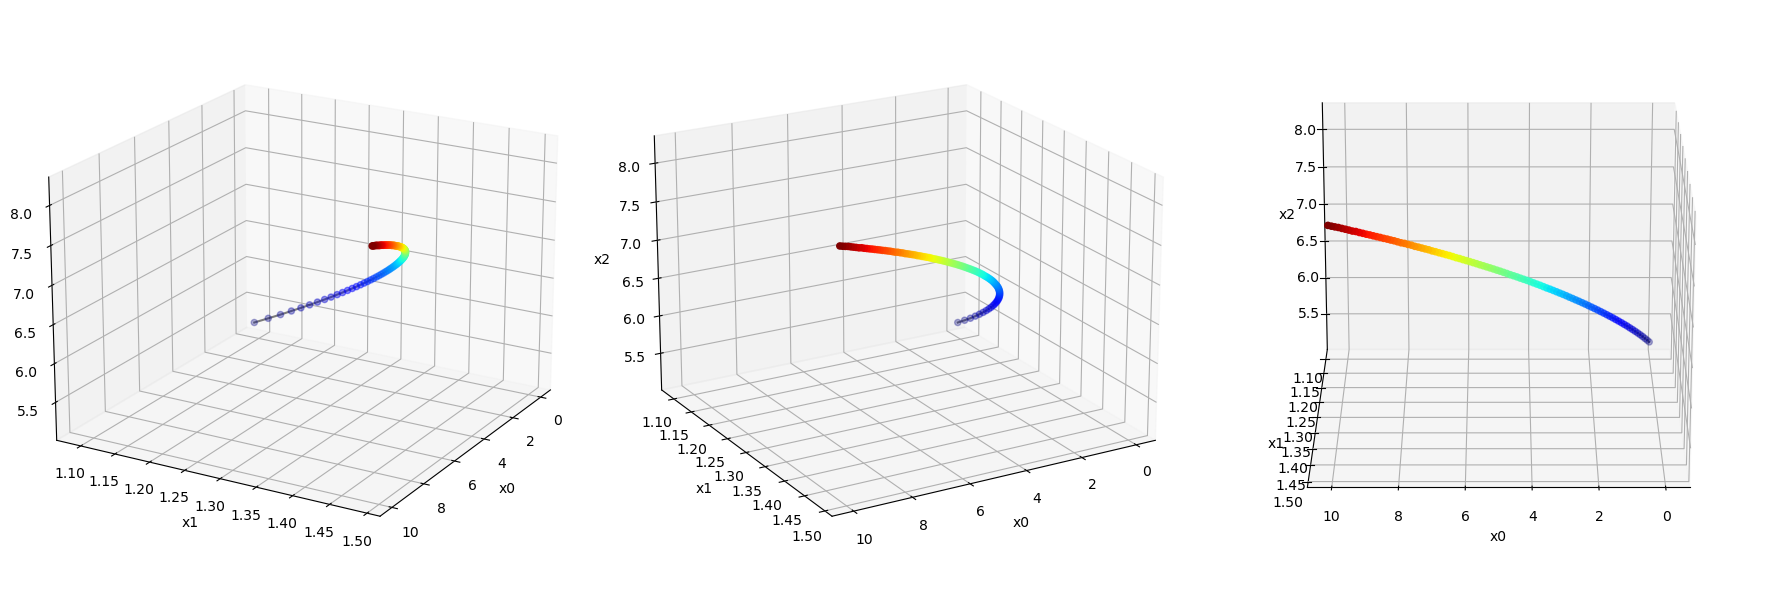

In [20]:
import numpy as np
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Define your function exponential_numerical_3p here
def exponential_numerical_3p(x, A, C, T_1):
    return A * np.exp(-x / T_1) + C

gamma_relax = 1.0
B = gamma_relax
T_1 = 1 / gamma_relax
T = 1

# Define your objective function
def objective_function(x, t):
    x0, x1, x2 = x

    A = 1
    C = 0
    y0 = exponential_numerical_3p(x0, A, C, T_1)
    y1 = exponential_numerical_3p(x1, A, C, T_1)
    y2 = exponential_numerical_3p(x2, A, C, T_1)

    sigma_gamma = np.sqrt(
        -y0
        * (y0 - 1)
        * (np.exp(x1 * B) - np.exp(x2 * B)) ** 4
        * (3 * t + x0 + x1 + x2)
        * np.exp(-2 * (-x0 + x1 + x2) * B)
        / (
            T
            * (
                x0 * y1 * np.exp(x1 * B)
                - x0 * y1 * np.exp(x2 * B)
                - x0 * y2 * np.exp(x1 * B)
                + x0 * y2 * np.exp(x2 * B)
                - x1 * y1 * np.exp(x0 * B)
                + x1 * y1 * np.exp(x2 * B)
                + x1 * y2 * np.exp(x0 * B)
                - x1 * y2 * np.exp(x2 * B)
                + x2 * y1 * np.exp(x0 * B)
                - x2 * y1 * np.exp(x1 * B)
                - x2 * y2 * np.exp(x0 * B)
                + x2 * y2 * np.exp(x1 * B)
            )
            ** 2
        )
    ) - y1 * (-y0 + y2) ** 2 * (
        y1 - 1
    ) * (
        np.exp(x1 * B) - np.exp(x2 * B)
    ) ** 4 * (
        3 * t + x0 + x1 + x2
    ) * np.exp(
        -2 * (-x0 + x1 + x2) * B
    ) / (
        T
        * (
            y1 - y2
        )
        ** 4
        * (
            x0 * np.exp(x1 * B)
            - x0 * np.exp(x2 * B)
            - x1 * np.exp(x0 * B)
            + x1 * np.exp(x2 * B)
            + x2 * np.exp(x0 * B)
            - x2 * np.exp(x1 * B)
        )
        ** 2
    ) - y2 * (
        y0 - y1
    ) ** 2 * (
        y2 - 1
    ) * (
        np.exp(x1 * B) - np.exp(x2 * B)
    ) ** 4 * (
        3 * t + x0 + x1 + x2
    ) * np.exp(
        -2 * (-x0 + x1 + x2) * B
    ) / (
        T
        * (
            y1 - y2
        )
        ** 4
        * (
            x0 * np.exp(x1 * B)
            - x0 * np.exp(x2 * B)
            - x1 * np.exp(x0 * B)
            + x1 * np.exp(x2 * B)
            + x2 * np.exp(x0 * B)
            - x2 * np.exp(x1 * B)
        )
        ** 2
    )

    return sigma_gamma / gamma_relax ** 2

# List of t values
t_values = np.linspace(0.01, 10, 100)

# Store the results for each t
results = []

for t in t_values:
    result = differential_evolution(
        lambda x: objective_function(x, t), bounds=[(0, 100), (0, 100), (0, 100)], tol=1e-6
    )
    sorted_result = np.sort(result.x)
    sorted_result[0] = t  # Replace the smallest value with t
    results.append(sorted_result)

# Convert the results to a numpy array for plotting
results = np.array(results)

# Create a color map
norm = plt.Normalize(t_values.min(), t_values.max())
colors = cm.jet(norm(results[:, 0]))

# Plot the results
fig = plt.figure(figsize=(18, 6))

# First subplot
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(results[:, 0], results[:, 1], results[:, 2], color='k', alpha=0.5)
ax1.scatter(results[:, 0], results[:, 1], results[:, 2], c=colors, cmap='jet')
ax1.set_xlabel('x0')
ax1.set_ylabel('x1')
ax1.set_zlabel('x2')
ax1.view_init(elev=20, azim=30)

# Second subplot
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(results[:, 0], results[:, 1], results[:, 2], color='k', alpha=0.5)
ax2.scatter(results[:, 0], results[:, 1], results[:, 2], c=colors, cmap='jet')
ax2.set_xlabel('x0')
ax2.set_ylabel('x1')
ax2.set_zlabel('x2')
ax2.view_init(elev=20, azim=60)

# Third subplot
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(results[:, 0], results[:, 1], results[:, 2], color='k', alpha=0.5)
ax3.scatter(results[:, 0], results[:, 1], results[:, 2], c=colors, cmap='jet')
ax3.set_xlabel('x0')
ax3.set_ylabel('x1')
ax3.set_zlabel('x2')
ax3.view_init(elev=20, azim=90)

plt.tight_layout()
plt.show()


/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_96954/1790662393.py:129: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax1.scatter(results[:, 0], results[:, 1], results[:, 2], c=colors, cmap='jet')
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_96954/1790662393.py:138: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax2.scatter(results[:, 0], results[:, 1], results[:, 2], c=colors, cmap='jet')
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_96954/1790662393.py:147: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax3.scatter(results[:, 0], results[:, 1], results[:, 2], c=colors, cmap='jet')


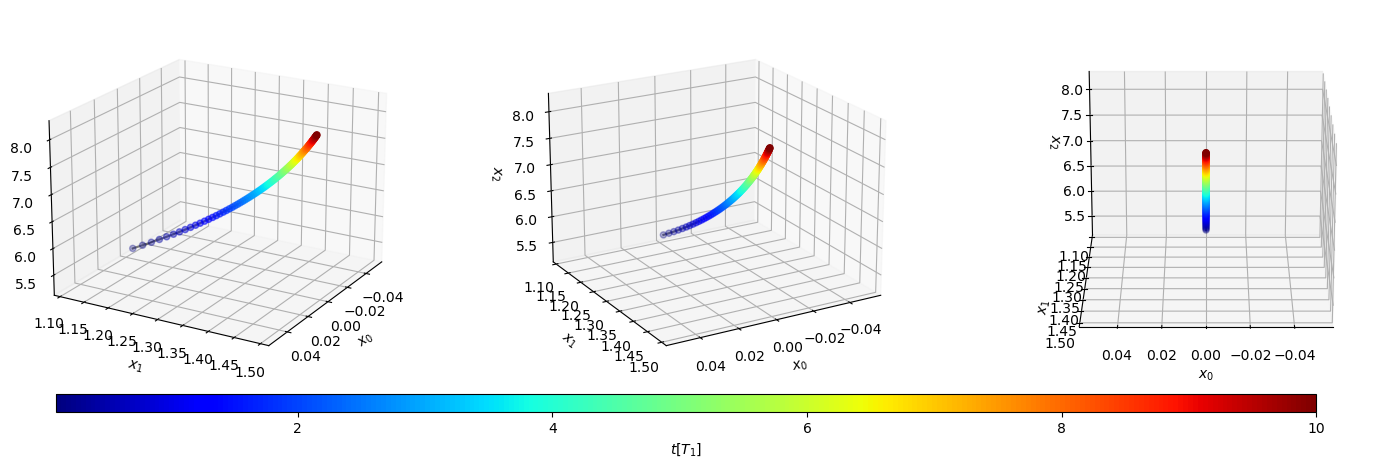

In [5]:
import numpy as np
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Define your function exponential_numerical_3p here
def exponential_numerical_3p(x, A, C, T_1):
    return A * np.exp(-x / T_1) + C

gamma_relax = 1.0
B = gamma_relax
T_1 = 1 / gamma_relax
T = 1

# Define your objective function
def objective_function(x, t):
    x0, x1, x2 = x

    A = 1
    C = 0
    y0 = exponential_numerical_3p(x0, A, C, T_1)
    y1 = exponential_numerical_3p(x1, A, C, T_1)
    y2 = exponential_numerical_3p(x2, A, C, T_1)

    sigma_gamma = np.sqrt(
        -y0
        * (y0 - 1)
        * (np.exp(x1 * B) - np.exp(x2 * B)) ** 4
        * (3 * t + x0 + x1 + x2)
        * np.exp(-2 * (-x0 + x1 + x2) * B)
        / (
            T
            * (
                x0 * y1 * np.exp(x1 * B)
                - x0 * y1 * np.exp(x2 * B)
                - x0 * y2 * np.exp(x1 * B)
                + x0 * y2 * np.exp(x2 * B)
                - x1 * y1 * np.exp(x0 * B)
                + x1 * y1 * np.exp(x2 * B)
                + x1 * y2 * np.exp(x0 * B)
                - x1 * y2 * np.exp(x2 * B)
                + x2 * y1 * np.exp(x0 * B)
                - x2 * y1 * np.exp(x1 * B)
                - x2 * y2 * np.exp(x0 * B)
                + x2 * y2 * np.exp(x1 * B)
            )
            ** 2
        )
    ) - y1 * (-y0 + y2) ** 2 * (
        y1 - 1
    ) * (
        np.exp(x1 * B) - np.exp(x2 * B)
    ) ** 4 * (
        3 * t + x0 + x1 + x2
    ) * np.exp(
        -2 * (-x0 + x1 + x2) * B
    ) / (
        T
        * (
            y1 - y2
        )
        ** 4
        * (
            x0 * np.exp(x1 * B)
            - x0 * np.exp(x2 * B)
            - x1 * np.exp(x0 * B)
            + x1 * np.exp(x2 * B)
            + x2 * np.exp(x0 * B)
            - x2 * np.exp(x1 * B)
        )
        ** 2
    ) - y2 * (
        y0 - y1
    ) ** 2 * (
        y2 - 1
    ) * (
        np.exp(x1 * B) - np.exp(x2 * B)
    ) ** 4 * (
        3 * t + x0 + x1 + x2
    ) * np.exp(
        -2 * (-x0 + x1 + x2) * B
    ) / (
        T
        * (
            y1 - y2
        )
        ** 4
        * (
            x0 * np.exp(x1 * B)
            - x0 * np.exp(x2 * B)
            - x1 * np.exp(x0 * B)
            + x1 * np.exp(x2 * B)
            + x2 * np.exp(x0 * B)
            - x2 * np.exp(x1 * B)
        )
        ** 2
    )

    return sigma_gamma / gamma_relax ** 2

# List of t values
t_values = np.linspace(0.1, 10, 100)

# Store the results for each t
results = []

for t in t_values:
    result = differential_evolution(
        lambda x: objective_function(x, t), bounds=[(0, 100), (0, 100), (0, 100)], tol=1e-6
    )
    sorted_result = np.sort(result.x)
    
    results.append(sorted_result)

# Convert the results to a numpy array for plotting
results = np.array(results)

# Create a color map
norm = plt.Normalize(t_values.min(), t_values.max())
colors = cm.jet(norm(t_values))

# Plot the results
fig = plt.figure(figsize=(18, 6))

# First subplot
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(results[:, 0], results[:, 1], results[:, 2], color='k', alpha=0.5)
ax1.scatter(results[:, 0], results[:, 1], results[:, 2], c=colors, cmap='jet')
ax1.set_xlabel(r'$x_0$')
ax1.set_ylabel(r'$x_1$')
ax1.set_zlabel(r'$x_2$')
ax1.view_init(elev=20, azim=30)

# Second subplot
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(results[:, 0], results[:, 1], results[:, 2], color='k', alpha=0.5)
ax2.scatter(results[:, 0], results[:, 1], results[:, 2], c=colors, cmap='jet')
ax2.set_xlabel(r'$x_0$')
ax2.set_ylabel(r'$x_1$')
ax2.set_zlabel(r'$x_2$')
ax2.view_init(elev=20, azim=60)

# Third subplot
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(results[:, 0], results[:, 1], results[:, 2], color='k', alpha=0.5)
ax3.scatter(results[:, 0], results[:, 1], results[:, 2], c=colors, cmap='jet')
ax3.set_xlabel(r'$x_0$')
ax3.set_ylabel(r'$x_1$')
ax3.set_zlabel(r'$x_2$')
ax3.view_init(elev=20, azim=90)

# Add colorbar
fig.subplots_adjust(bottom=0.25)
cax = fig.add_axes([0.15, 0.21, 0.7, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap='jet'), cax=cax, ax=[ax1, ax2, ax3], orientation='horizontal', pad=0.1)
cbar.set_label(r'$t[T_1] $')


# Save figure as high-quality PNG
plt.savefig('3poptevolution.png', dpi=300)
plt.show()
